In [1]:
import cv2
import torch

# 设置matplotlib后端，避免渲染器问题
import matplotlib
matplotlib.use('Agg')  # 使用非交互式后端
from matplotlib import pyplot as plt

from util.utils import load_state_dict, load_checkpoint
from util.visualize import plot_bounding_boxes_on_image

/root/miniconda3/envs/detr/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/root/miniconda3/envs/detr/lib/python3.8/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [ ]:
# paq-dino: use branch v3.3.1-clean from branch
# orig-dino: use branch dab-def-dn-decoder-query-optm-v1.0
# orig-def-detr: use branch dab-def-dn-decoder-query-optm-v1.0
from configs.dino_pp.dino_pp_resnet50_800_1333 import model
model_path = "/root/autodl-tmp/orig-dino/best_ap.pth"
weight = load_checkpoint(model_path)
load_state_dict(model, weight)
model = model.eval()

Using /root/.cache/torch_extensions/py38_cu113 as PyTorch extensions root...
Detected CUDA files, patching ldflags
Emitting ninja build file /root/.cache/torch_extensions/py38_cu113/MultiScaleDeformableAttention/build.ninja...
Building extension module MultiScaleDeformableAttention...
Allowing ninja to set a default number of workers... (overridable by setting the environment variable MAX_JOBS=N)
ninja: no work to do.
Loading extension module MultiScaleDeformableAttention...


In [3]:
image = cv2.imread("/root/autodl-tmp/COCO2017/val2017/000000000139.jpg")
torch_image = torch.tensor(image.transpose(2, 0, 1))

In [4]:
with torch.no_grad():
    predictions = model([torch_image])[0]
# The following code also works:
# predictions = model(torch_image.unsqueeze(0))[0]

In [5]:
# 检查 predictions 的内容
print("predictions keys:", predictions.keys())
print("\nPredictions structure:")
for key, value in predictions.items():
    if isinstance(value, torch.Tensor):
        print(f"  {key}: shape={value.shape}, dtype={value.dtype}")
    else:
        print(f"  {key}: type={type(value)}")

predictions keys: dict_keys(['pred_logits', 'pred_boxes', 'aux_outputs', 'enc_outputs', 'original_image_sizes'])

Predictions structure:
  pred_logits: shape=torch.Size([1, 900, 91]), dtype=torch.float32
  pred_boxes: shape=torch.Size([1, 900, 4]), dtype=torch.float32
  aux_outputs: type=<class 'list'>
  enc_outputs: type=<class 'dict'>
  original_image_sizes: shape=torch.Size([1, 2]), dtype=torch.int64


In [6]:
# 手动处理原始预测结果
# predictions 包含: 'pred_logits' [1, 900, 91] 和 'pred_boxes' [1, 900, 4]

# 1. 获取logits并转为概率
pred_logits = predictions["pred_logits"][0]  # [900, 91]
pred_boxes = predictions["pred_boxes"][0]     # [900, 4] (cx, cy, w, h) 归一化坐标

# 2. 转为概率（sigmoid）
probs = pred_logits.sigmoid()  # [900, 91]

# 3. 获取每个query的最大概率和对应类别
scores, labels = probs.max(dim=-1)  # scores: [900], labels: [900]

# 4. 筛选高置信度的预测（例如 > 0.3）
confidence_threshold = 0.3
mask = scores > confidence_threshold

filtered_scores = scores[mask]
filtered_labels = labels[mask]
filtered_boxes = pred_boxes[mask]

# 5. 转换box格式: (cx, cy, w, h) -> (x1, y1, x2, y2)
# 并转换为图像坐标
from torchvision.ops import box_convert
h, w = image.shape[:2]

# 先转换格式
boxes_xyxy = box_convert(filtered_boxes, in_fmt='cxcywh', out_fmt='xyxy')
# 再转换为绝对坐标
boxes_xyxy[:, [0, 2]] *= w
boxes_xyxy[:, [1, 3]] *= h

print(f"原始queries数量: {pred_logits.shape[0]}")
print(f"筛选后检测数量: {filtered_scores.shape[0]}")
print(f"置信度范围: {filtered_scores.min():.3f} - {filtered_scores.max():.3f}")

原始queries数量: 900
筛选后检测数量: 22
置信度范围: 0.312 - 0.857


In [7]:
image_for_show = plot_bounding_boxes_on_image(
    image=cv2.cvtColor(image, cv2.COLOR_BGR2RGB),
    boxes=boxes_xyxy,  # 使用手动处理的boxes
    labels=filtered_labels,  # 使用手动处理的labels
    scores=filtered_scores,  # 使用手动处理的scores
    classes=model.CLASSES,  # class information
    show_conf=0.3,  # 降低阈值，因为我们已经在上面筛选过了
    font_scale=1.0,
    box_thick=2,
    text_alpha=0.75,
)

✓ 检测结果已保存到: output_detection.jpg


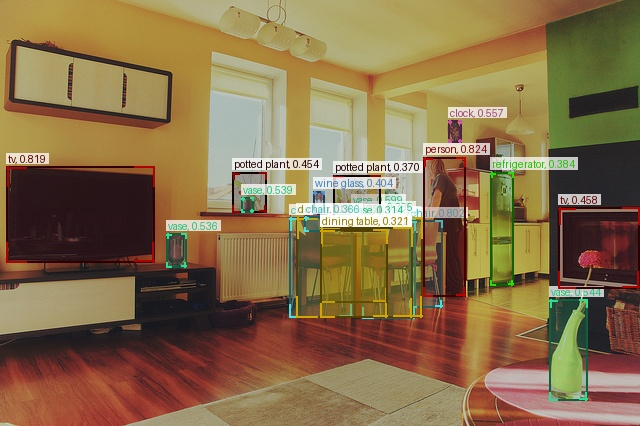

In [8]:
# 保存图像到文件（避免渲染器问题）
output_path = "output_detection.jpg"
cv2.imwrite(output_path, cv2.cvtColor(image_for_show, cv2.COLOR_RGB2BGR))
print(f"✓ 检测结果已保存到: {output_path}")

# 如果想在notebook中显示，使用 IPython.display
from IPython.display import Image, display
display(Image(filename=output_path))

In [ ]:
plt.imshow(image_for_show)

In [ ]:
# ========================================
# 在Validation Set上计算Gini和Pareto@20
# ========================================

import numpy as np
import torch
from tqdm import tqdm
from torch.utils.data import DataLoader
from datasets.coco import CocoDetection

# ========== 可调整参数 ==========
ACTIVATION_THRESHOLD = 0.5   # Query激活阈值
NUM_SAMPLES = 5000            # 处理的图像数量（全集5000张）
# ================================

print(f"📋 配置参数:")
print(f"   激活阈值: {ACTIVATION_THRESHOLD}")
print(f"   处理样本数: {NUM_SAMPLES}")
print()

# 1. 加载COCO验证集
coco_val = CocoDetection(
    img_folder="/root/autodl-tmp/COCO2017/val2017",
    ann_file="/root/autodl-tmp/COCO2017/annotations/instances_val2017.json",
    transforms=None,  # 不需要预处理
    train=False       # 验证集模式
)

# 自定义collate函数：将numpy转为tensor（模型会自动处理resize和normalize）
def simple_collate(batch):
    images, targets = [], []
    for img, target in batch:
        # 将numpy array转为tensor
        if isinstance(img, np.ndarray):
            img = torch.from_numpy(img)
        images.append(img)
        targets.append(target)
    return list(zip(images, targets))

val_loader = DataLoader(
    coco_val, 
    batch_size=1, 
    shuffle=False, 
    num_workers=2,
    collate_fn=simple_collate
)

print(f"✓ Validation set loaded: {len(coco_val)} images")
print(f"✓ 模型会自动处理：resize、normalize等预处理")

In [ ]:
# 2. 在验证集上收集query激活统计
num_queries = 900
query_activation_counts = torch.zeros(num_queries)

# ========== 使用GPU加速 ==========
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 使用设备: {device}")
model = model.to(device)
model.eval()
# ================================

with torch.no_grad():
    for idx, batch in enumerate(tqdm(val_loader, desc="Processing validation set")):
        if idx >= NUM_SAMPLES:
            break
            
        # 获取图像
        img_data, target = batch[0]
        images = [img_data.to(device)]  # 将图像移到GPU
        
        # 推理
        outputs = model(images)[0]
        
        # 获取预测
        pred_logits = outputs["pred_logits"][0]  # [900, 91]
        probs = pred_logits.sigmoid()
        
        # 统计每个query的最大概率（激活强度）
        max_probs, _ = probs.max(dim=-1)  # [900]
        
        # 如果概率超过阈值，认为该query被激活
        activated = (max_probs > ACTIVATION_THRESHOLD).float()
        
        query_activation_counts += activated.cpu()

print(f"\n✓ Processed {min(NUM_SAMPLES, len(coco_val))} images")
print(f"✓ Total activations: {query_activation_counts.sum().item():.0f}")
print(f"✓ Avg activations per image: {query_activation_counts.sum().item() / min(NUM_SAMPLES, len(coco_val)):.2f}")

In [ ]:
# 3. 计算Gini系数和Pareto@20
def compute_gini(counts):
    """
    计算Gini系数
    Gini = 0: 完全平等（所有queries激活次数相同）
    Gini = 1: 完全不平等（只有一个query被激活）
    """
    counts = np.array(counts)
    n = len(counts)
    
    # 按升序排序
    sorted_counts = np.sort(counts)
    
    # 计算Gini系数
    index = np.arange(1, n + 1)
    gini = (2 * np.sum(index * sorted_counts)) / (n * np.sum(sorted_counts)) - (n + 1) / n
    
    return gini

def compute_pareto(counts, percent=20):
    """
    计算Pareto@X: 前X%的queries占据总激活的百分比
    例如 Pareto@20 = 0.8 表示前20%的queries占据了80%的激活
    """
    counts = np.array(counts)
    total = counts.sum()
    
    if total == 0:
        return 0.0
    
    # 按降序排序
    sorted_counts = np.sort(counts)[::-1]
    
    # 计算前X%的queries
    top_k = int(len(counts) * percent / 100)
    top_k_sum = sorted_counts[:top_k].sum()
    
    return top_k_sum / total

# 计算指标
activation_counts_np = query_activation_counts.numpy()
gini = compute_gini(activation_counts_np)
pareto_20 = compute_pareto(activation_counts_np, percent=20)

print(f"\n📊 Query Usage Statistics:")
print(f"   Gini Coefficient: {gini:.3f}")
print(f"   Pareto@20: {pareto_20:.3f}")
print(f"\n解读:")
print(f"   - Gini={gini:.3f}: {'不均衡' if gini > 0.5 else '相对均衡'}的query使用分布")
print(f"   - Pareto@20={pareto_20:.3f}: 前20%的queries占{pareto_20*100:.1f}%的激活")

In [ ]:
# 4. 绘制Query激活分布图（类似论文图表）
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.size'] = 12

# 按激活次数降序排序
sorted_counts = np.sort(activation_counts_np)[::-1]
query_indices = np.arange(len(sorted_counts))

# 创建图表
fig, ax = plt.subplots(figsize=(8, 6))

# 绘制激活曲线（对数刻度）
ax.plot(query_indices, sorted_counts, linewidth=2, color='#2E86AB')
ax.set_yscale('log')

# 添加20%分界线
pareto_line_x = int(len(sorted_counts) * 0.2)
ax.axvline(x=pareto_line_x, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

# 设置标签
ax.set_xlabel('Query Index (Ranked)', fontsize=14, fontweight='bold')
ax.set_ylabel('Activation Count (log)', fontsize=14, fontweight='bold')
# gini; pareto_20
ax.set_title(f'Gini={gini:.3f}, Pareto={pareto_20:.3f}', fontsize=16, fontweight='bold')

# 网格
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(0, len(sorted_counts))

# 设置y轴范围（避免0值问题）
min_val = max(sorted_counts[sorted_counts > 0].min() if (sorted_counts > 0).any() else 1e-1, 1e-1)
ax.set_ylim(min_val, sorted_counts.max() * 1.5)

plt.tight_layout()

# 保存图像
output_file = f"query_distribution_gini_{gini:.3f}_pareto_{pareto_20:.3f}.png"
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"\n✓ 图表已保存到: {output_file}")

plt.show()

In [ ]:
# 5. 详细分析（可选）
print("\n📈 详细统计:")
print(f"   最常用query: 激活 {sorted_counts[0]:.0f} 次")
print(f"   中位数: 激活 {np.median(sorted_counts):.0f} 次")
print(f"   最少用query: 激活 {sorted_counts[-1]:.0f} 次")
print(f"   未激活queries: {(activation_counts_np == 0).sum()} / {len(activation_counts_np)}")

# Pareto分析
print(f"\n   前10%queries占比: {compute_pareto(activation_counts_np, 10):.3f}")
print(f"   前20%queries占比: {compute_pareto(activation_counts_np, 20):.3f}")
print(f"   前50%queries占比: {compute_pareto(activation_counts_np, 50):.3f}")